# 01 — Random Forest on Band-Power Features

Trains a Random Forest classifier on log mu (8–13 Hz) + log beta (13–30 Hz)
band-power features extracted from 3 motor channels (C3, Cz, C4).

Evaluates both candidate windows ([0.0, 4.0] and [0.5, 2.5] seconds), picks
the winner by val macro-F1, and computes test metrics on the winning window
only. See `PIPELINE_PLAN.md` §5.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.run_01_random_forest import main as run_rf


## Train + evaluate

In [2]:
run_rf()

Loaded split: train 80 val 12 test 12
Feature names: ['C3_8-13Hz', 'C3_13-30Hz', 'Cz_8-13Hz', 'Cz_13-30Hz', 'C4_8-13Hz', 'C4_13-30Hz']

=== Window w0.0-4.0 ===
  epochs: train=1849 val=340 test=296
  best CV params: {'rf__max_depth': 10, 'rf__min_samples_leaf': 1}  best CV macroF1: 0.5638
  trained in 7.2s
  val accuracy: 0.6441 | macroF1: 0.6411

=== Window w0.5-2.5 ===
  epochs: train=2142 val=373 test=361
  best CV params: {'rf__max_depth': 10, 'rf__min_samples_leaf': 1}  best CV macroF1: 0.5573
  trained in 5.9s
  val accuracy: 0.5684 | macroF1: 0.5669

=== Winning window: w0.0-4.0 (val macroF1 0.6411) ===
Test metrics: {'accuracy': 0.5574324324324325, 'macro_f1': 0.5504075504075504, 'per_class_f1': [0.6066066066066066, 0.4942084942084942], 'confusion_matrix': [[101, 45], [86, 64]]}
Saved model → /Users/luke/Desktop/Personal Projects/eeg-prediction/models/rf_w0.0-4.0.joblib
Saved → /Users/luke/Desktop/Personal Projects/eeg-prediction/reports/rf_results.json


## Inspect saved results

In [3]:
import json
result = json.loads((ROOT / 'reports' / 'rf_results.json').read_text())
print('Winning window:', result['winning_window'])
print('Test metrics:')
for k, v in result['test_metrics'].items():
    print(f'  {k}: {v}')
print('Top features:')
for name, imp in sorted(result['feature_importances'].items(), key=lambda kv: -kv[1])[:6]:
    print(f'  {name}: {imp:.4f}')


Winning window: [0.0, 4.0]
Test metrics:
  accuracy: 0.5574324324324325
  macro_f1: 0.5504075504075504
  per_class_f1: [0.6066066066066066, 0.4942084942084942]
  confusion_matrix: [[101, 45], [86, 64]]
Top features:
  C4_8-13Hz: 0.1979
  C3_8-13Hz: 0.1933
  C4_13-30Hz: 0.1707
  C3_13-30Hz: 0.1483
  Cz_8-13Hz: 0.1463
  Cz_13-30Hz: 0.1435


## Confusion matrix and feature importance

Saved alongside the JSON in `reports/figures/`:
- `rf_confusion.png` — 2x2 normalised confusion matrix on test
- `rf_feature_importance.png` — top RF feature importances


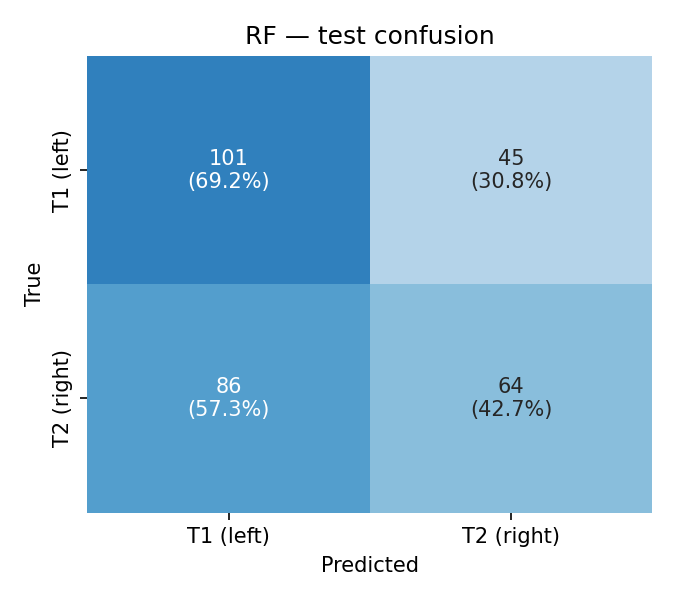

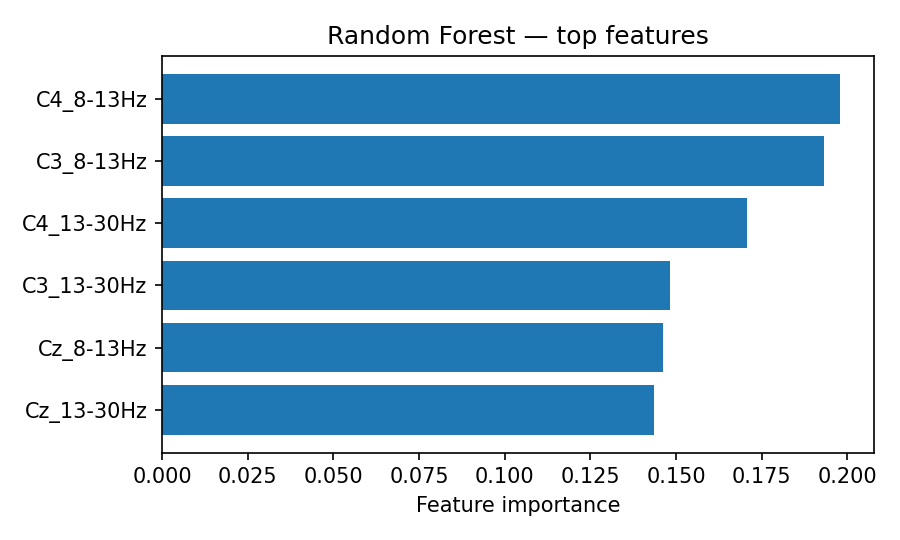

In [4]:
from IPython.display import Image, display
display(Image(str(ROOT / 'reports' / 'figures' / 'rf_confusion.png')))
display(Image(str(ROOT / 'reports' / 'figures' / 'rf_feature_importance.png')))
